# MMI714: Homework — Distribution Distances in 1D

**Middle East Technical University**

Due: Monday, November 7, 23:59 (ODTUClass)

## Introduction. 

This homework helps you see how three distances behave on simple 1D data:
KL, Jensen–Shannon (JS), and Wasserstein-1 (W1). You will compare basic distri-
butions, visualize histograms and CDFs, and comment on when metrics agree or disagree.
Keep code minimal; focus on clear figures and short explanations.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
SEED = 42
DEFAULT_SMOOTH = 1e-8 # additive smoothing for histogram counts
RNG = np.random.default_rng(SEED)
outdir = "outputs"
os.makedirs(outdir, exist_ok=True)


In [3]:
# ---- Generators ----

def make_gaussian(n: int, mean = 0.0, std= 1.0, rng=RNG) -> np.ndarray:
    return rng.normal(mean,std,size=n)

def make_bimodal(n: int, mean1 = -2.0, std1= 1.0, mean2=2.0, std2=0.7, p=0.5, rng=RNG) -> np.ndarray:
    k= rng.binomial(1, p, size=n)
    x = rng.normal(mean1, std1, size=n)
    y= rng.normal(mean2, std2, size=n)
    return np.where(k==1, x, y)

def make_student_t(n: int, df=3, loc=0.0, scale=1.0, rng=RNG) -> np.ndarray:
    return loc + scale * rng.standard_t(df, size=n)



In [4]:
# ---- Utilities ----
def common_range(x: np.ndarray, y: np.ndarray, lo_pct=0.1, hi_pct=99.9):
    lo = min(np.percentile(x, lo_pct), np.percentile(y, lo_pct))
    hi = max(np.percentile(x, hi_pct), np.percentile(y, hi_pct))
    span = hi - lo
    return lo - 0.05 * span, hi + 0.05 * span

def histogram_pmf(x: np.ndarray, bins: int , range_, smoothing: float = DEFAULT_SMOOTH):
    counts, edges = np.histogram(x, bins=bins, range=range_)
    countss = counts.astype(float) + smoothing
    pmf = counts/ counts.sum()
    return pmf, edges

def kl_divergence(p: np.ndarray, q: np.ndarray)-> float:
    eps = 1e-15
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return float(np.sum(p*(np.log(p)-np.log(q))))

def js_divergence(p: np.ndarray, q: np.ndarray) -> float:
    eps = 1e-15
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * (np.log2(p) - np.log2(m)))
    kl_qm = np.sum(q * (np.log2(q) - np.log2(m)))
    return float(0.5 * (kl_pm + kl_qm))

def w1_from_hist(p: np.ndarray, q: np.ndarray, edges: np.ndarray) -> float:
    cdf_p = np.cumsum(p)
    cdf_q = np.cumsum(q)
    widths = np.diff(edges)
    diff = np.abs(cdf_p - cdf_q)
    return float(np.sum(diff * widths))

def metrics_table_for_bins(P:np.ndarray, Q:np.ndarray, bin_counts, smoothing: float, range_):
    rows = []
    for b in bin_counts:
        p, edges = histogram_pmf(P, bins=b, range_=range_, smoothing=smoothing)
        q, _ = histogram_pmf(Q, bins=b, range_=range_, smoothing=smoothing)
        rows.append(dict(
                    bins=b,
                    KL_PQ=kl_divergence(p, q),
                    KL_QP=kl_divergence(q, p),
                    JS=js_divergence(p, q),
                    W1=w1_from_hist(p, q, edges),
        ))
    return pd.DataFrame(rows)

def make_disagreement_pairs(n=10_000):
    # (i) W1 large, JS small: small mass far away (large shift cost, small overlap change)
    base = make_gaussian(n,0.0,1.0)
    k= RNG.binomial(1, 0.05, size=n) # 5% mass far
    tail = RNG.normal(25.0, 0.5, size=n)
    Q_far = np.where(k==1, tail, base)
    pair_i = (base, Q_far, 'Same Gaussian + 5% far tail')

    # (ii) JS large, W1 moderate: interleaved supports (even vs odd bins)
    B = 100
    edges = np.linspace(0.0,1.0,B+1)
    centers= 0.5 * (edges[:-1] + edges[1:])
    even_mask = np.arange(B) % 2 == 0
    odds_mask = ~even_mask
    n_even = even_mask.sum()
    n_odd = odds_mask.sum()
    P_centers = np.repeat(centers[even_mask], repeats=n//n_even +1)[:n]
    Q_centers = np.repeat(centers[odds_mask], repeats=n//n_odd +1)[:n]
    jitter = 0.25 * (edges[1] - edges[0])
    P = P_centers + RNG.normal(0, jitter, size=n)
    Q = Q_centers + RNG.normal(0, jitter, size=n)
    pair_ii = (P, Q, 'Interleaved supports (even vs odd bins)')

    return {
        'W1-large_JS-small': pair_i,
        'JS-large_W1-moderate': pair_ii,
    }





In [5]:
def plot_cdfs(P: np.ndarray, Q: np.ndarray, bins: int, range_, title: str, outpath: str, smoothing: float = DEFAULT_SMOOTH):
        p, edges = histogram_pmf(P, bins=bins, range_=range_, smoothing=smoothing)
        q, _ = histogram_pmf(Q, bins=bins, range_=range_, smoothing=smoothing)
        cdf_p = np.concatenate([[0.0], np.cumsum(p)])
        cdf_q = np.concatenate([[0.0], np.cumsum(q)])
        x = edges
        abs_diff = np.abs(cdf_p - cdf_q)
        w1 = w1_from_hist(p, q, edges)

        plt.figure(figsize=(7.5, 4.5))
        plt.subplot(1, 2, 1)
        plt.step(x, cdf_p, where='post', label='F_P')
        plt.step(x, cdf_q, where='post', label='F_Q')
        plt.title(f'{title}\nEmpirical CDFs')
        plt.xlabel('x'); plt.ylabel('F(x)'); plt.legend()

        plt.subplot(1, 2, 2)
        plt.step(x, abs_diff, where='post', color='tab:red')
        plt.title(f'|F_P - F_Q|, approx W1 = {w1:.4f}')
        plt.xlabel('x'); plt.ylabel('|ΔCDF|')
        plt.tight_layout()
        plt.savefig(outpath, dpi=150)
        plt.show()
        plt.close()
        return w1


## Problem 1. 

Two simple sources (warm-up). Create two 1D samples (each N ≥5,000):
pick any Gaussian distribution and any non-Gaussian distribution (e.g., a two-peak mixture,
uniform, or Student-t). Plot normalized histograms on the same axis using the same bin
edges. Write 1 short paragraph describing visible differences (location, spread, tails, or
modes).

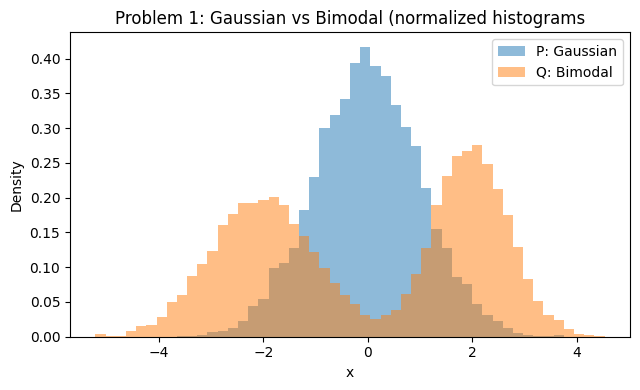

In [8]:
N1 = 10_000
P1 = make_gaussian(N1, mean=0.0, std=1.0)
Q1 = make_bimodal(N1, mean1=-2.0, std1=1.0, mean2=2.0, std2=0.7, p=0.5)
r1 = common_range(P1, Q1)
bins1 = 50

plt.figure(figsize=(6.5, 4.0))
plt.hist(P1, bins=bins1, range=r1, density=True, alpha=0.5, label='P: Gaussian')
plt.hist(Q1, bins=bins1, range=r1, density=True, alpha=0.5, label='Q: Bimodal')
plt.title('Problem 1: Gaussian vs Bimodal (normalized histograms')
plt.xlabel('x'); plt.ylabel('Density'); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(outdir, 'p1_hist.png'), dpi=150)
plt.show()

## Problem 2. 

KL, JS, W1 under different binnings. Using the same bin edges for both
distributions from Problem 1, compute for three bin counts (e.g., 20 / 50 / 100):
$$
KL(P ∥Q), KL(Q∥P ), JS(P, Q), W1(P, Q).
$$

Use a small additive smoothing (state its value) to avoid log 0 in KL/JS. Present a table
(rows = bin counts; columns = distances). Add 2–3 sentences: how did binning/smoothing
affect the numbers?

In [9]:
bin_counts = [20, 50, 100]
smoothing = DEFAULT_SMOOTH
df_p2 = metrics_table_for_bins(P1, Q1, bin_counts, smoothing, range_=r1)
display(df_p2)
df_p2.to_csv(os.path.join(outdir, 'p2_metrics.csv'), index=False)
print(f'smoothing used: {smoothing}')

,bins,KL_PQ,KL_QP,JS,W1
0,20,1.143377,1.826877,0.357629,1.220529
1,50,1.181773,2.032207,0.365496,1.213223
2,100,1.197325,2.243022,0.368269,1.213028


smoothing used: 1e-08


## Problem 3. 

“Metrics disagree” counterexample. Tweak or design a new pair so that
either (i) W1 is large while JS is small or (ii) JS is large while W1 is moderate. Provide
an overlay histogram and a short explanation of why the disagreement occurs (e.g., small
shift vs. support gap vs. mode drop). Include KL(P ∥Q) and KL(Q∥P ) in your table and
comment on asymmetry.

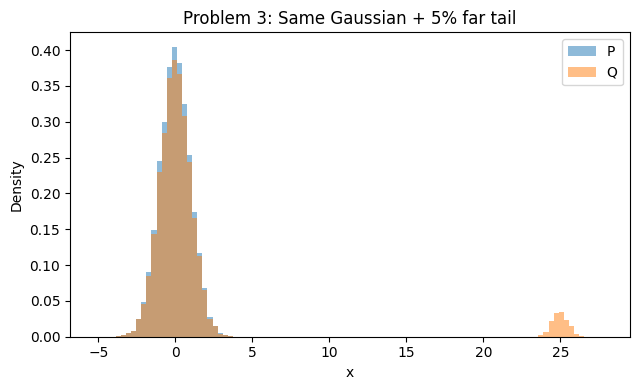

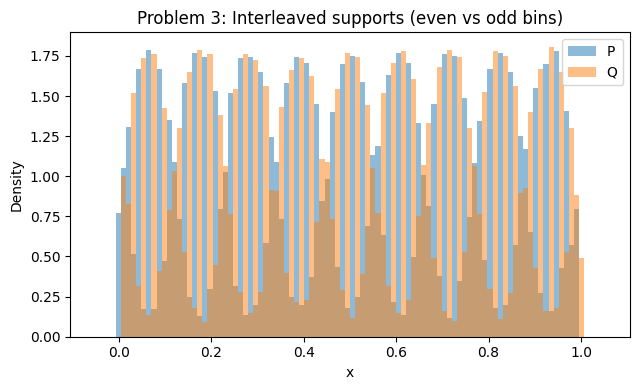

,case,KL_PQ,KL_QP,JS,W1_hist,W1_samples
0,W1-large_JS-small,0.048090,1.343354,0.023875,1.172607,1.173007
1,JS-large_W1-moderate,1.201721,1.091351,0.295657,0.010034,0.010012


In [ ]:
pairs = make_disagreement_pairs(n=10_000)
rows = []
for key, (P,Q,name) in pairs.items():
    r3 = common_range(P, Q, lo_pct=0.01, hi_pct=99.99)
    # overlay histogram
    plt.figure(figsize=(6.5, 4.0))
    plt.hist(P, bins=100, range=r3, density=True, alpha=0.5, label='P')
    plt.hist(Q, bins=100, range=r3, density=True, alpha=0.5, label='Q')
    plt.title(f'Problem 3: {name}')
    plt.xlabel('x'); plt.ylabel('Density'); plt.legend(); plt.tight_layout()
    fname= f'p3_{key}_hist.png'
    plt.savefig(os.path.join(outdir, fname), dpi=150)
    plt.show()
    # metrics (hist-based + sample W1)
    p,edges = histogram_pmf(P, bins=100, range_=r3, smoothing=DEFAULT_SMOOTH)
    q,_ = histogram_pmf(Q, bins=100, range_=r3, smoothing= DEFAULT_SMOOTH)
    rows.append(dict(
        case=key,
        KL_PQ=kl_divergence(p, q),
        KL_QP=kl_divergence(q, p),
        JS=js_divergence(p, q),
        W1_hist=w1_from_hist(p, q, edges),
        W1_samples=wasserstein_distance(P, Q),
    ))
df_p3 = pd.DataFrame(rows)
display(df_p3)
df_p3.to_csv(os.path.join(outdir, 'p3_metrics.csv'), index=False)

## Problem 4. 

CDF lens for Wasserstein. For one pair from Problems 1–3, plot the
empirical CDFs and the curve of $ |FP(x) −FQ(x)| $  over x. Report W1 and explain, in a few
sentences, how the CDF picture corresponds to the value.

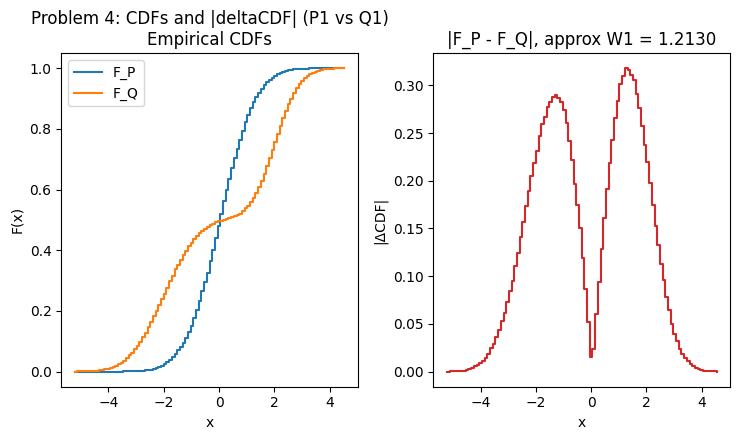

Approximate W1 from histograms (area under |delta CDF|): 1.213028


In [ ]:
w1_p4 = plot_cdfs(P1, Q1, bins=100, range_=r1,
                  title='Problem 4: CDFs and |deltaCDF| (P1 vs Q1)',
                  outpath=os.path.join(outdir, 'p4_cdfs.png'),
                  smoothing=DEFAULT_SMOOTH)
print(f'Approximate W1 from histograms (area under |delta CDF|): {w1_p4:.6f}')

## Sample-size sensitivity. 

Fix one pair. For N ∈ {200, 1,000, 5,000, 20,000},
recompute KL/JS/W1 (use your best bin setting from Problem 2). Plot distance vs. N for
all three metrics on one figure. Write a short paragraph: which metric stabilizes fastest?
which is most variable, and why do you think so?

In [ ]:
Ns = [200, 1_000, 5_000, 20_000]
best_bins = 50  # from Problem 2 as a stable mid setting
rows = []
for N in Ns:
    Pn = make_gaussian(N, 0.0, 1.0)
    Qn = make_bimodal(N, -2.0, 1.0, 2.0, 0.7, 0.5)
    rn = common_range(Pn, Qn)
    p,edges = histogram_pmf(Pn, bins=best_bins, range_=rn, smoothing=DEFAULT_SMOOTH)
    q,_ = histogram_pmf(Qn, bins=best_bins, range_=rn, smoothing=DEFAULT_SMOOTH)
    rows.append(dict(
        N=N,
        KL_PQ=kl_divergence(p, q),
        KL_QP=kl_divergence(q, p),
        JS= js_divergence(p, q),
        W1=w1_from_hist(p, q, edges),
    ))
df_p5 = pd.DataFrame(rows)
display(df_p5)
df_p5.to_csv(os.path.join(outdir, 'p2_vs_N.csv'), index=False)

plt.figure(figsize=(6.5,4.0))
for col in ['KL_PQ', 'KL_QP', 'JS', 'W1']:
    plt.plot(df_p5['N'], df_p5[col], marker='o', label=col)
plt.xscale('log')
plt.title('Problem 5: Distance vs Sample Size')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(outdir, 'p5_vs_N.png'), dpi=150)
plt.show()

In [ ]:
#Optional:writemethodssummary